Please upload your Sample - Superstore.csv file


Saving Sample - Superstore.csv to Sample - Superstore (1).csv
Dataset loaded successfully!
Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lau

/tmp/ipykernel_4314/3629378901.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('Discount_Bucket')['Profit'].sum()



Top 10 Customers by Order Count:
Customer Name
Emily Phan             17
Sally Hughsby          13
Noel Staavos           13
Patrick Gardner        13
Zuschuss Carroll       13
Joel Eaton             13
Erin Ashbrook          13
Chloris Kastensmidt    13
Suzanne McNair         12
Rick Bensley           12
Name: Order ID, dtype: int64

PRODUCT ANALYSIS
Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                    

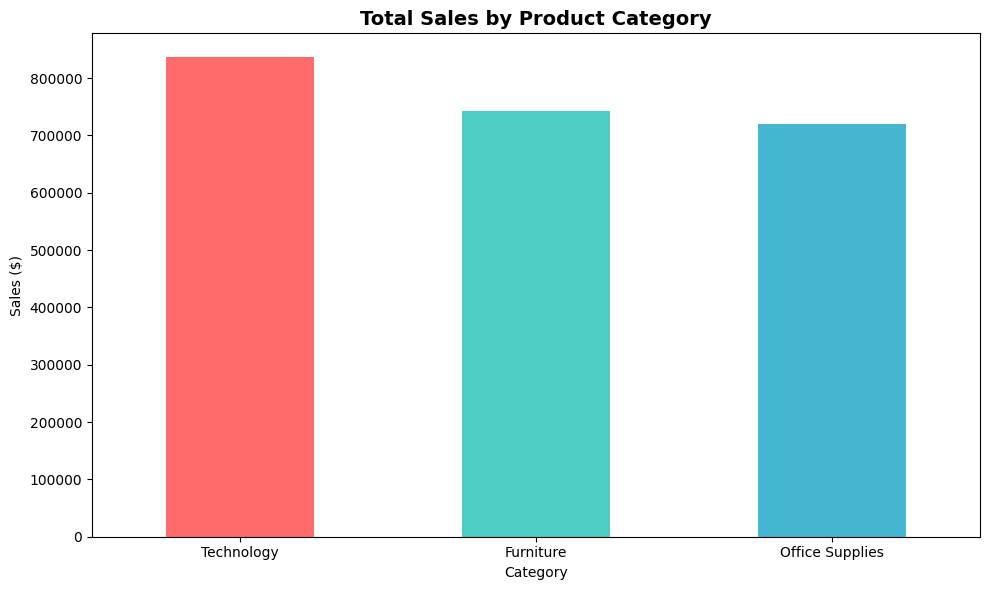

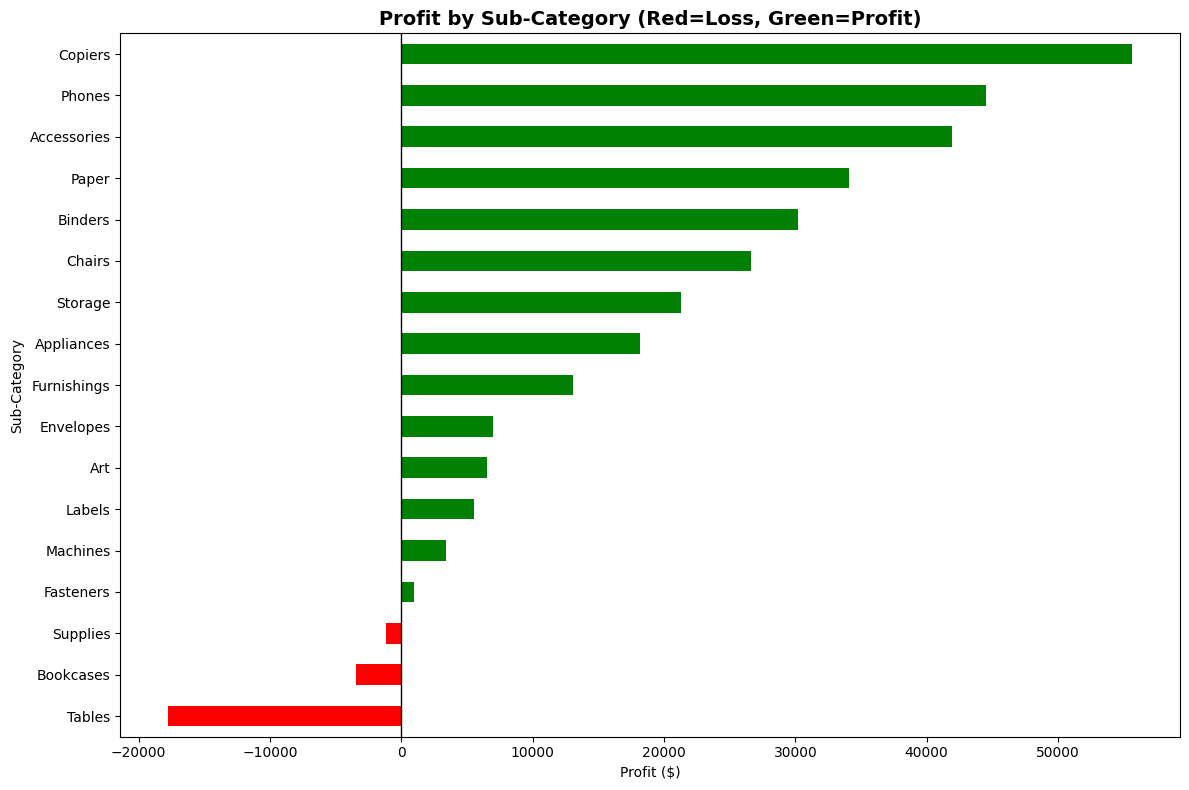

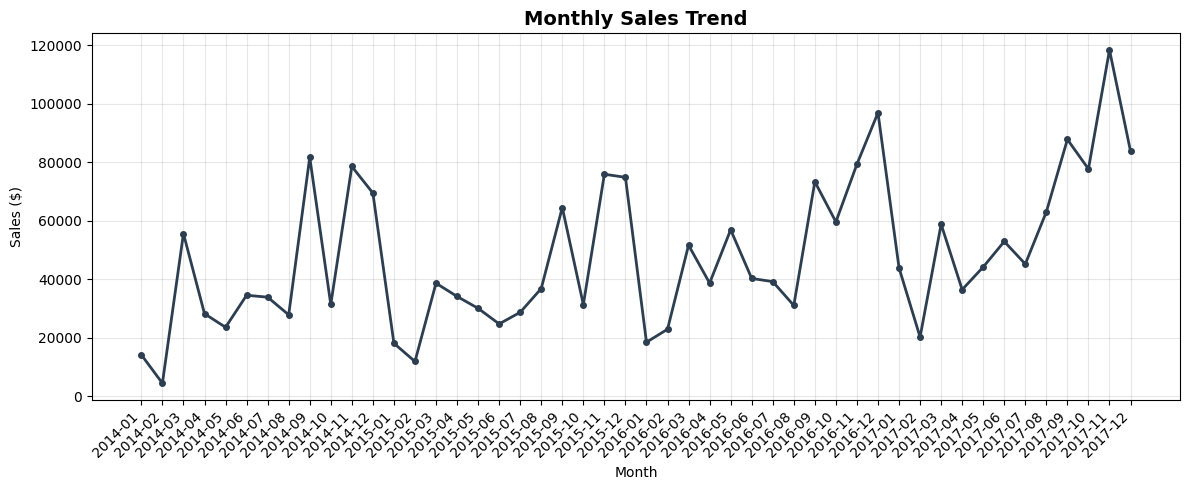

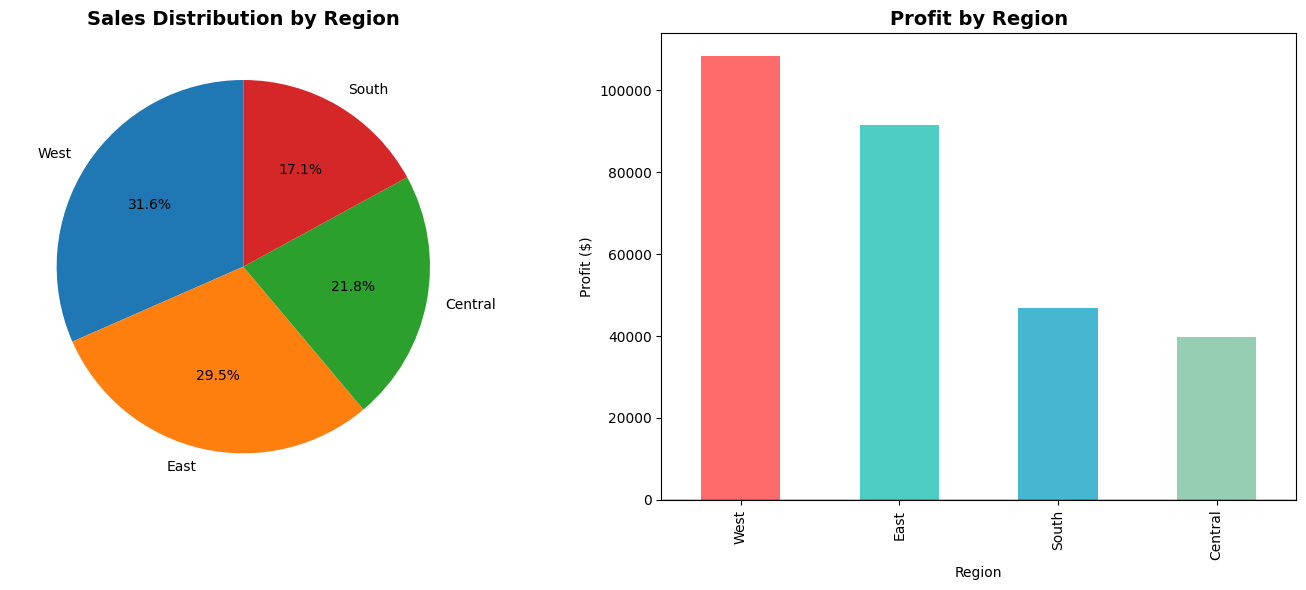

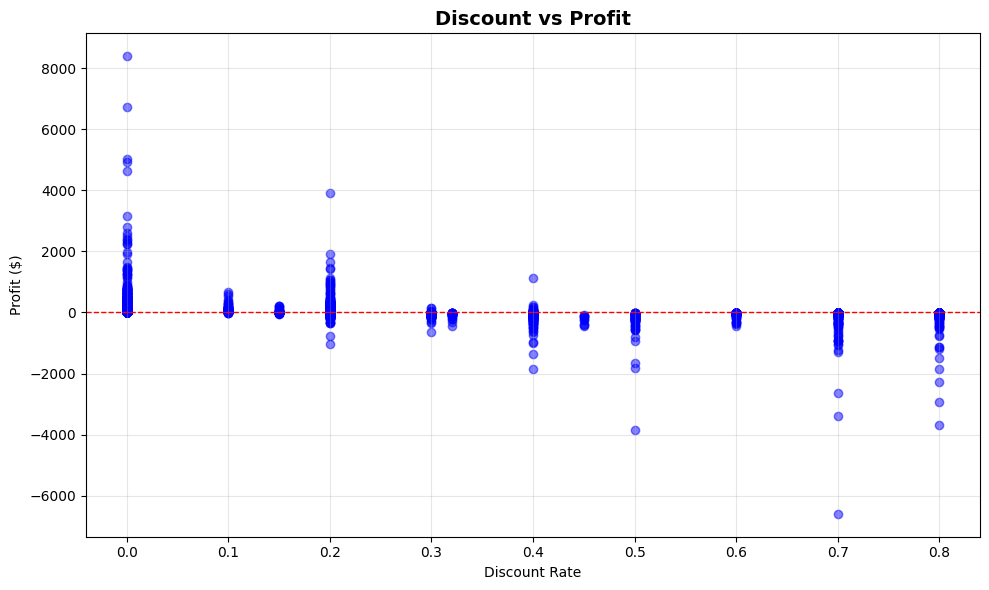

/tmp/ipykernel_4314/3629378901.py:236: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount_Bucket', y='Profit', data=df, palette='viridis')


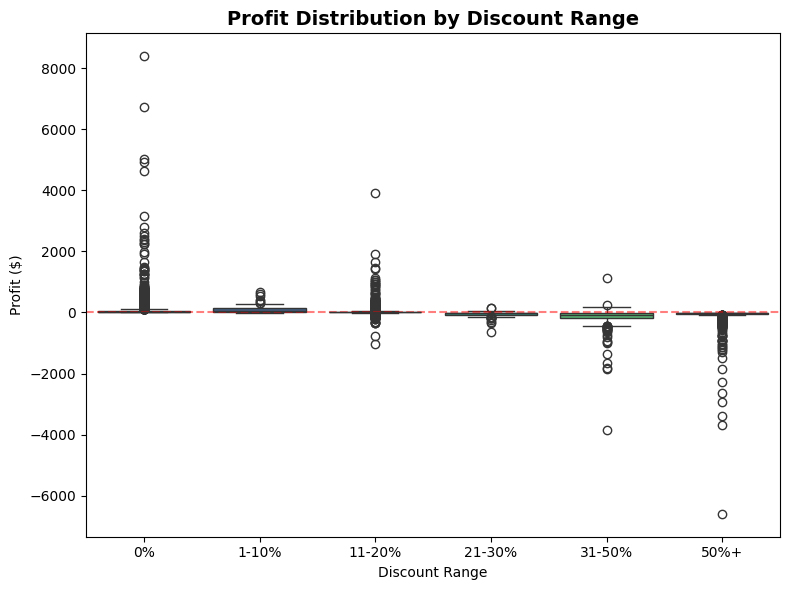

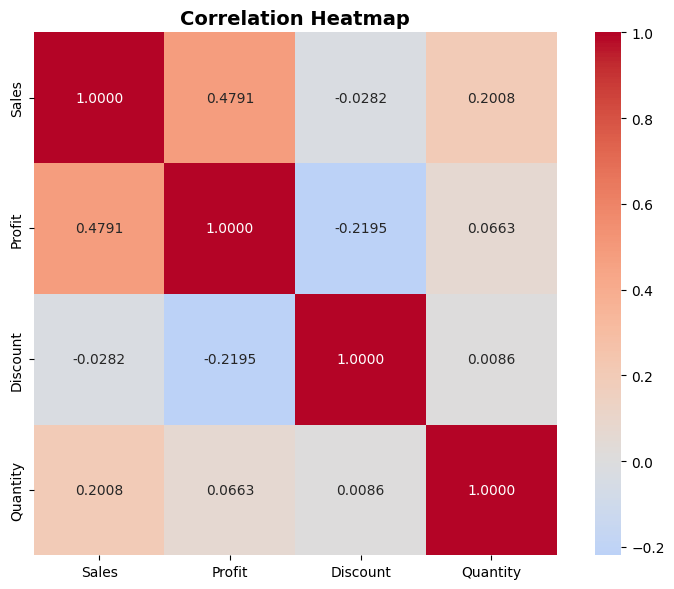

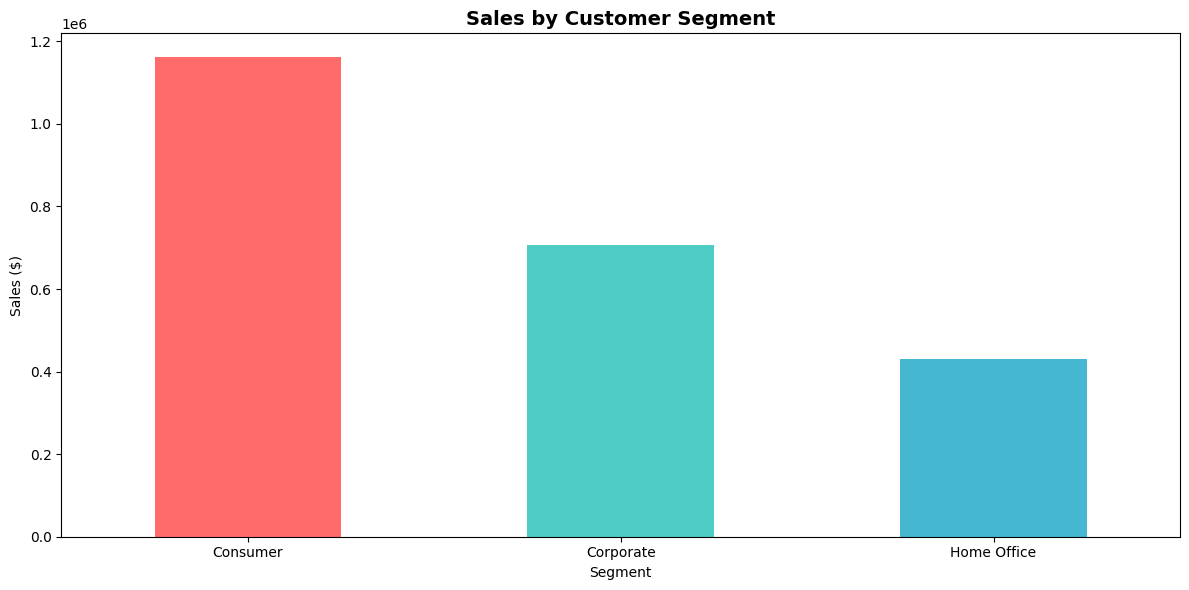

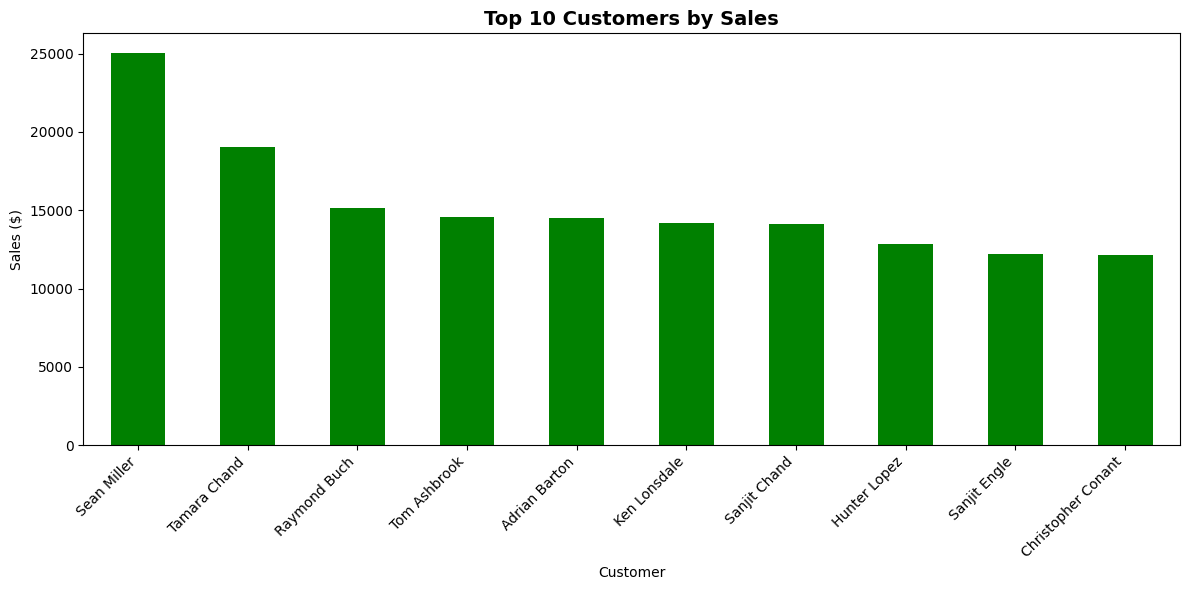

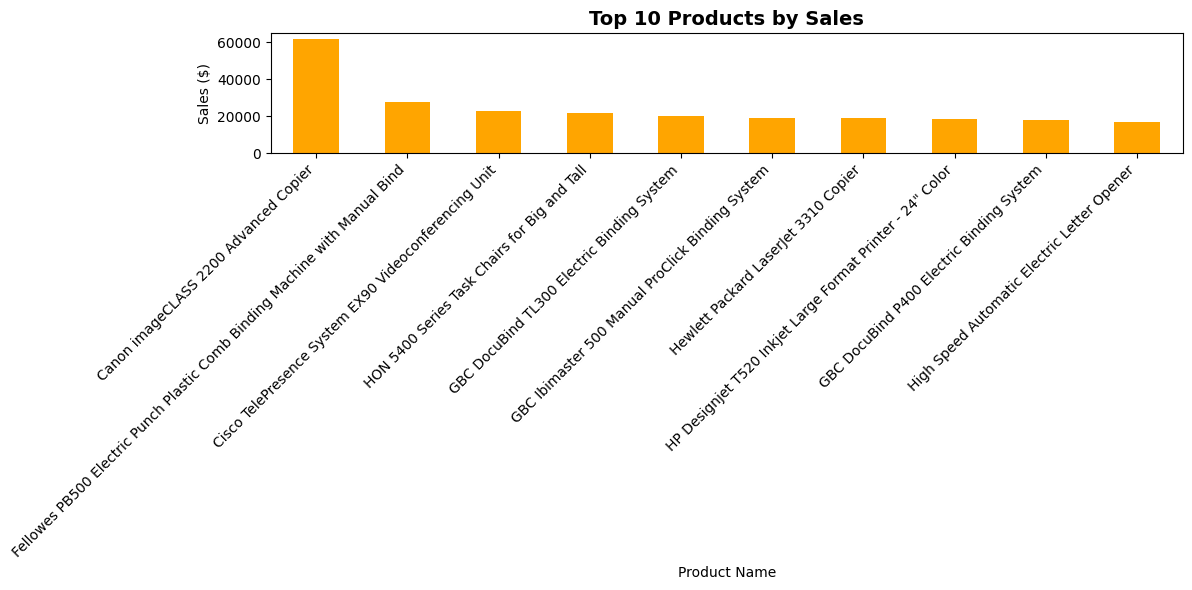

KEY FINDINGS & INSIGHTS

1. SALES INSIGHTS
   - Top Category: Technology with $836,154.03
   - Top Region: West with $725,457.82
   - Top Segment: Consumer with $1,161,401.34
   - Best Month: Month 11

2. PROFIT INSIGHTS
   - Most Profitable Category: Technology
   - Most Profitable Sub-Category: Copiers
   - Least Profitable Sub-Category: Tables
   - Total Loss Amount: $-156,131.29

3. DISCOUNT INSIGHTS
   - Category with Highest Avg Discount: Furniture
   - Profit with NO discount: $320,987.60
   - Profit with discount: $-34,590.58
   - Discounts above 50% cause significant losses

4. CORRELATION INSIGHTS
   - Sales and Profit correlation: 0.4791
   - Discount and Profit correlation: -0.2195
   - Quantity and Sales correlation: 0.2008

RECOMMENDATIONS

1. SALES STRATEGY
   - Increase marketing budget for Technology category
   - Focus on Consumer segment for targeted campaigns
   - Expand successful strategies from top region to others
   - Plan inventory for peak months

2. PROFIT O

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Files ready for submission!
Upload to GitHub and share the link on Thiranex portal.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
print("Please upload your Sample - Superstore.csv file")
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), encoding='latin1')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

df['Order Date'] = pd.to_datetime(df['Order Date'])

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Date Range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

print(df[['Sales', 'Profit', 'Discount', 'Quantity']].describe())

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)

print(df.isnull().sum())

print("\n" + "="*60)
print("SALES ANALYSIS")
print("="*60)

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Category:")
print(category_sales)

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Region:")
print(region_sales)

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Customer Segment:")
print(segment_sales)

ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Ship Mode:")
print(ship_sales)

print("\n" + "="*60)
print("PROFIT ANALYSIS")
print("="*60)

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Category:")
print(category_profit)

subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print("\nTop 5 Most Profitable Sub-Categories:")
print(subcat_profit.head(5))
print("\nBottom 5 Least Profitable Sub-Categories:")
print(subcat_profit.tail(5))

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Region:")
print(region_profit)

negative_profit = df[df['Profit'] < 0]
print(f"\nTotal Loss Amount: ${negative_profit['Profit'].sum():,.2f}")
print(f"Number of Loss Orders: {len(negative_profit)}")
print(f"Percentage of Loss Orders: {len(negative_profit)/len(df)*100:.2f}%")

print("\n" + "="*60)
print("DISCOUNT ANALYSIS")
print("="*60)

discount_category = df.groupby('Category')['Discount'].mean()
print("\nAverage Discount by Category:")
print(discount_category)

no_discount_profit = df[df['Discount'] == 0]['Profit'].sum()
with_discount_profit = df[df['Discount'] > 0]['Profit'].sum()
print(f"\nProfit with NO discount: ${no_discount_profit:,.2f}")
print(f"Profit with discount: ${with_discount_profit:,.2f}")

high_discount = df[df['Discount'] > 0.5]
print(f"\nOrders with >50% discount: {len(high_discount)}")
print(f"Profit from >50% discount orders: ${high_discount['Profit'].sum():,.2f}")

df['Discount_Bucket'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1],
                               labels=['0%', '1-10%', '11-20%', '21-30%', '31-50%', '50%+'])

discount_profit = df.groupby('Discount_Bucket')['Profit'].sum()
print("\nProfit by Discount Range:")
print(discount_profit)

print("\n" + "="*60)
print("TIME-BASED ANALYSIS")
print("="*60)

df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Weekday'] = df['Order Date'].dt.day_name()

monthly_sales = df.groupby('Month')['Sales'].sum()
print("\nMonthly Sales:")
for month in range(1, 13):
    print(f"  Month {month}: ${monthly_sales.get(month, 0):,.2f}")

best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()
print(f"\nBest month for sales: Month {best_month}")
print(f"Worst month for sales: Month {worst_month}")

yearly_sales = df.groupby('Year')['Sales'].sum()
print("\nYearly Sales:")
for year in yearly_sales.index:
    print(f"  {year}: ${yearly_sales[year]:,.2f}")

weekday_sales = df.groupby('Weekday')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Weekday:")
print(weekday_sales)

print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

correlation = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()
print("Correlation Matrix:")
print(correlation)

print("\nKey Correlation Insights:")
print(f"  Sales vs Profit: {correlation.loc['Sales','Profit']:.4f}")
print(f"  Sales vs Discount: {correlation.loc['Sales','Discount']:.4f}")
print(f"  Sales vs Quantity: {correlation.loc['Sales','Quantity']:.4f}")
print(f"  Discount vs Profit: {correlation.loc['Discount','Profit']:.4f}")

print("\n" + "="*60)
print("CUSTOMER ANALYSIS")
print("="*60)

top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Sales:")
print(top_customers)

top_profit_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Customers by Profit:")
print(top_profit_customers)

customer_orders = df.groupby('Customer Name')['Order ID'].nunique().sort_values(ascending=False).head(10)
print("\nTop 10 Customers by Order Count:")
print(customer_orders)

print("\n" + "="*60)
print("PRODUCT ANALYSIS")
print("="*60)

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Sales:")
print(top_products)

top_profit_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products by Profit:")
print(top_profit_products)

bottom_profit_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=True).head(10)
print("\nBottom 10 Products by Profit (Losses):")
print(bottom_profit_products)

plt.figure(figsize=(10,6))
category_sales.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
profit_data = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in profit_data]
profit_data.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category (Red=Loss, Green=Profit)', fontsize=14, fontweight='bold')
plt.xlabel('Profit ($)')
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
plt.plot(monthly.index.astype(str), monthly.values, marker='o', color='#2C3E50', linewidth=2, markersize=4)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14,6))
region_sales.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Sales Distribution by Region', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

region_profit.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1].set_title('Profit by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Profit ($)')
axes[1].axhline(y=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5, c='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x='Discount_Bucket', y='Profit', data=df, palette='viridis')
plt.title('Profit Distribution by Discount Range', fontsize=14, fontweight='bold')
plt.xlabel('Discount Range')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
corr = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.4f', square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
segment_sales.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Sales by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar', color='green')
plt.title('Top 10 Customers by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Customer')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
top_products.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Product Name')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("="*60)
print("KEY FINDINGS & INSIGHTS")
print("="*60)

print("\n1. SALES INSIGHTS")
print(f"   - Top Category: {category_sales.index[0]} with ${category_sales.iloc[0]:,.2f}")
print(f"   - Top Region: {region_sales.index[0]} with ${region_sales.iloc[0]:,.2f}")
print(f"   - Top Segment: {segment_sales.index[0]} with ${segment_sales.iloc[0]:,.2f}")
print(f"   - Best Month: Month {best_month}")

print("\n2. PROFIT INSIGHTS")
print(f"   - Most Profitable Category: {category_profit.index[0]}")
print(f"   - Most Profitable Sub-Category: {subcat_profit.index[0]}")
print(f"   - Least Profitable Sub-Category: {subcat_profit.index[-1]}")
print(f"   - Total Loss Amount: ${negative_profit['Profit'].sum():,.2f}")

print("\n3. DISCOUNT INSIGHTS")
print(f"   - Category with Highest Avg Discount: {discount_category.idxmax()}")
print(f"   - Profit with NO discount: ${no_discount_profit:,.2f}")
print(f"   - Profit with discount: ${with_discount_profit:,.2f}")
print(f"   - Discounts above 50% cause significant losses")

print("\n4. CORRELATION INSIGHTS")
print(f"   - Sales and Profit correlation: {correlation.loc['Sales','Profit']:.4f}")
print(f"   - Discount and Profit correlation: {correlation.loc['Discount','Profit']:.4f}")
print(f"   - Quantity and Sales correlation: {correlation.loc['Quantity','Sales']:.4f}")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

print("\n1. SALES STRATEGY")
print("   - Increase marketing budget for Technology category")
print("   - Focus on Consumer segment for targeted campaigns")
print("   - Expand successful strategies from top region to others")
print("   - Plan inventory for peak months")

print("\n2. PROFIT OPTIMIZATION")
print("   - Review pricing strategy for Tables and Bookcases")
print("   - Investigate loss-making Sub-Categories")
print("   - Focus on high-margin products")
print("   - Retain top profitable customers")

print("\n3. DISCOUNT POLICY")
print("   - Limit discounts to below 20%")
print("   - Avoid high discounts on low-margin products")
print("   - Use targeted discounts instead of blanket offers")

print("\n4. OPERATIONAL IMPROVEMENTS")
print("   - Reduce shipping time for better customer satisfaction")
print("   - Optimize inventory based on seasonal demand")
print("   - Focus on weekday sales peaks")

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS COMPLETED")
print("="*60)

df.to_csv('superstore_cleaned.csv', index=False)
files.download('superstore_cleaned.csv')

print("\nFiles ready for submission!")
print("Upload to GitHub and share the link on Thiranex portal.")